In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikitagupta1812/student-success-dataset/student_success_dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/nikitagupta1812/student-success-dataset/student_success_dataset.csv')

In [3]:
print("Sample Rows")
df.head()



Sample Rows


,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,65,No,6,Yes
2,6,85,70,Yes,7,Yes
3,1,50,30,No,4,No
4,3,70,55,Yes,6,Yes


In [4]:
print("Dataset Shape")
print(f'Rows:{df.shape[0]},columns={df.shape[1]}')

Dataset Shape
Rows:20,columns=6


In [5]:
print("Dataset Info")
print(df.info())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None


In [6]:
print ("Summary statistics")
print(df.describe())

Summary statistics
       StudyHours  Attendance  PastScore  SleepHours
count   20.000000   20.000000  20.000000   20.000000
mean     4.950000   74.550000  60.250000    6.250000
std      2.704285   17.150955  20.096805    1.915999
min      1.000000   40.000000  25.000000    3.000000
25%      2.750000   60.000000  43.750000    5.000000
50%      5.000000   77.500000  62.500000    6.000000
75%      7.000000   88.500000  73.500000    7.250000
max     10.000000   99.000000  92.000000   10.000000


In [7]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

print("After Encoding")


After Encoding


In [9]:
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,65,0,6,1
2,6,85,70,1,7,1
3,1,50,30,0,4,0
4,3,70,55,1,6,1


  ## PROJECT

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


In [11]:
df = pd.read_csv('/kaggle/input/datasets/nikitagupta1812/student-success-dataset/student_success_dataset.csv')

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



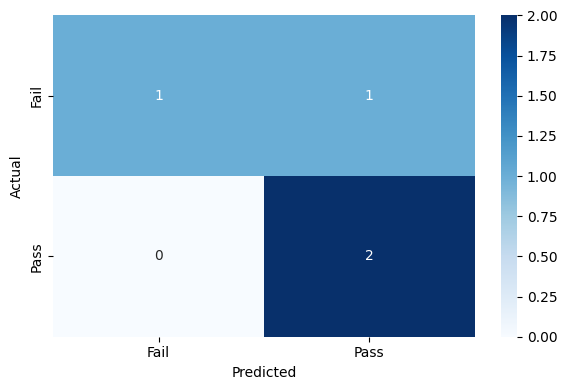

--------------------Predict Your Result--------------
An Error Occurred: raw_input was called, but this frontend does not support input requests.


In [12]:
#### from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Encoding
le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

# Features
features = ['StudyHours','Attendance','PastScore']

# Scaling
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Split
X = df_scaled[features]
y = df_scaled['Passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fail",'Pass'],
            yticklabels=["Fail","Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ---------------- USER INPUT ----------------
print("--------------------Predict Your Result--------------")

try:
    study_hours = float(input("Enter Study Hours: "))
    attendance = float(input("Enter Attendance: "))
    past_score = float(input("Enter Past Scores: "))

    # Input DataFrame (same features only)
    user_input_df = pd.DataFrame([{
        'StudyHours': study_hours,
        'Attendance': attendance,
        'PastScore': past_score
    }])

    # Scaling
    user_input_scaled = scaler.transform(user_input_df)

    # Prediction
    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction == 1 else "Fail"
    print(f"Prediction Based on input: {result}")

except Exception as e:
    print("An Error Occurred:", e)